<a href="https://colab.research.google.com/github/Pranayshukla0610/Python_Projects/blob/main/Linear_Regression_%26_Seaborn_Mastery_Complete_Exploratory_Data_Analysis_and_Predictive_Modeling_on_Indian_Housing_Rental_Market_in_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
class DataIngestion:
  def __init__(self, zip_path, extract_path):
    self.zip_path = zip_path
    self.extract_path = extract_path

  def verify_integrity(self):
    with open(self.zip_path, 'rb') as f:
      file_hash = hashlib.md5(f.read()).hexdigest()
    print(f"File Hash (for reproducibility): {file_hash}")

  def extract(self):
    with zipfile.ZipFile(self.zip_path, 'r') as zip_ref:
      zip_ref.extractall(self.extract_path)
    print("Extraction Done")

  def get_files(self):
    return os.listdir(self.extract_path)

In [4]:
import hashlib
import zipfile
import os

zip_path = '/content/archive (39).zip'
extract_path = '/content/'
ingestion = DataIngestion(zip_path, extract_path)
ingestion.verify_integrity()
ingestion.extract()
print(ingestion.get_files())

File Hash (for reproducibility): ee56539369e0de579320094316f7c3da
Extraction Done
['.config', 'archive (39).zip', 'data.csv', 'sample_data']


In [5]:
df = pd.read_csv('/content/data.csv')
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


In [6]:
print(df.shape)

(7691, 10)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB
None


In [8]:
print(df.describe())

               area         beds    bathrooms    balconies    area_rate  \
count   7691.000000  7691.000000  7691.000000  7691.000000  7691.000000   
mean    1106.354180     2.208685     2.137043     0.817319    47.619989   
std     1197.426843     0.993481     1.027677     1.243361    68.989657   
min        2.000000     1.000000     0.000000     0.000000     2.000000   
25%      600.000000     1.000000     1.000000     0.000000    21.000000   
50%      900.000000     2.000000     2.000000     0.000000    31.000000   
75%     1300.000000     3.000000     3.000000     2.000000    54.000000   
max    70000.000000    10.000000    10.000000    10.000000  2586.000000   

               rent  
count  7.691000e+03  
mean   5.479508e+04  
std    9.742006e+04  
min    1.000000e+03  
25%    1.500000e+04  
50%    2.800000e+04  
75%    5.700000e+04  
max    2.700000e+06  


In [9]:
print(df.isnull().sum())

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64


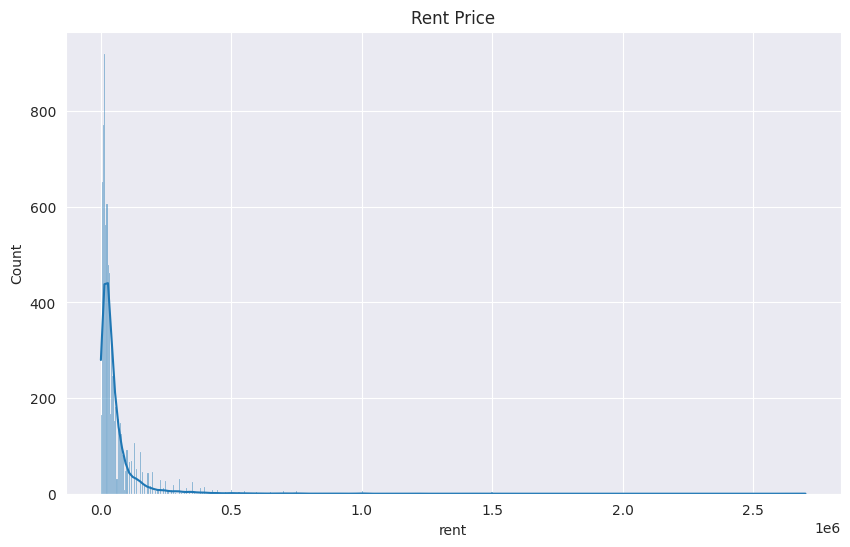

In [10]:
sns.histplot(df['rent'],kde=True)
plt.title('Rent Price')
plt.show()

In [11]:
print("""
INSIGHT:
- Rent distribution is right-skewed
- Presence of luxury house outliers
- Linear Regression assumes normality
- Log transformation may improve model performance
""")


INSIGHT:
- Rent distribution is right-skewed
- Presence of luxury house outliers
- Linear Regression assumes normality
- Log transformation may improve model performance



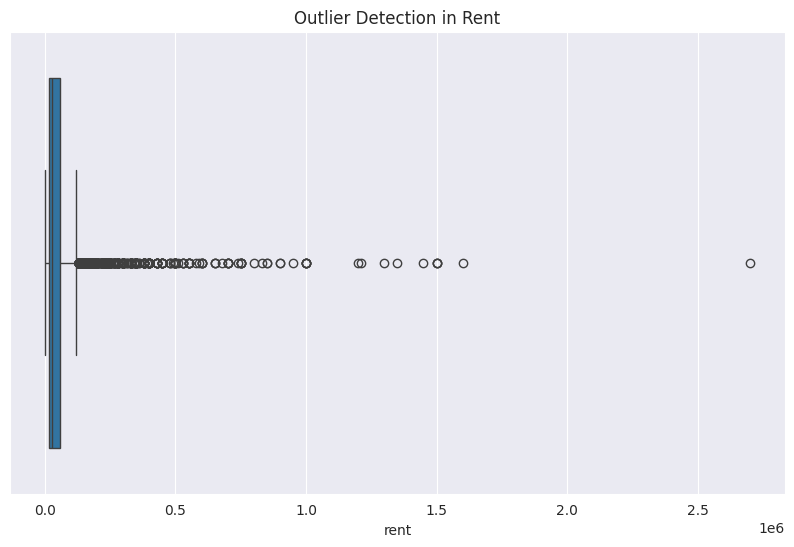

In [12]:
sns.boxplot(x=df['rent'])
plt.title('Outlier Detection in Rent')
plt.show()

In [13]:
print("""
INSIGHT:
- Extreme rent values exist
- Outliers can heavily affect Linear Regression line
- May increase RMSE significantly
- Need outlier treatment
""")


INSIGHT:
- Extreme rent values exist
- Outliers can heavily affect Linear Regression line
- May increase RMSE significantly
- Need outlier treatment



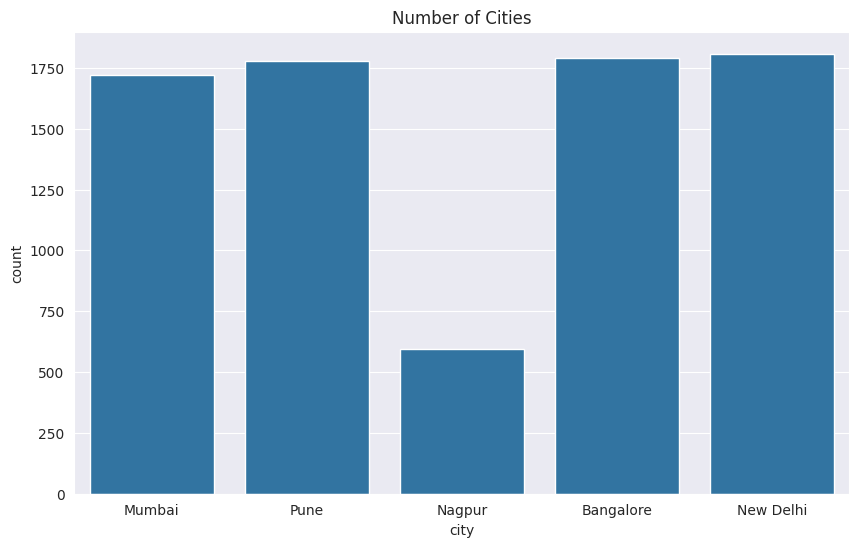

In [14]:
sns.countplot(data=df, x='city')
plt.title("Number of Cities")
plt.show()

In [15]:
print("""
INSIGHT:
- Dataset imbalance across cities
- Some cities dominate observations
- Model may become biased toward high-frequency cities
""")


INSIGHT:
- Dataset imbalance across cities
- Some cities dominate observations
- Model may become biased toward high-frequency cities



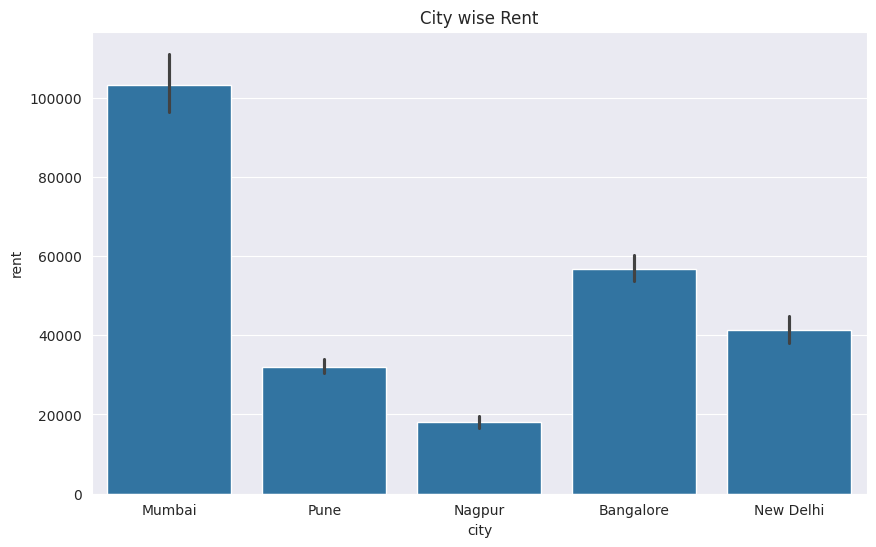

In [16]:
sns.barplot(data=df, x='city', y='rent')
plt.title('City wise Rent')
plt.show()

In [17]:
print("""
INSIGHT:
- Mumbai, Bangalore and Delhi have higher average rents
- City strongly influences rent prediction
- Important categorical feature for regression
""")


INSIGHT:
- Mumbai, Bangalore and Delhi have higher average rents
- City strongly influences rent prediction
- Important categorical feature for regression



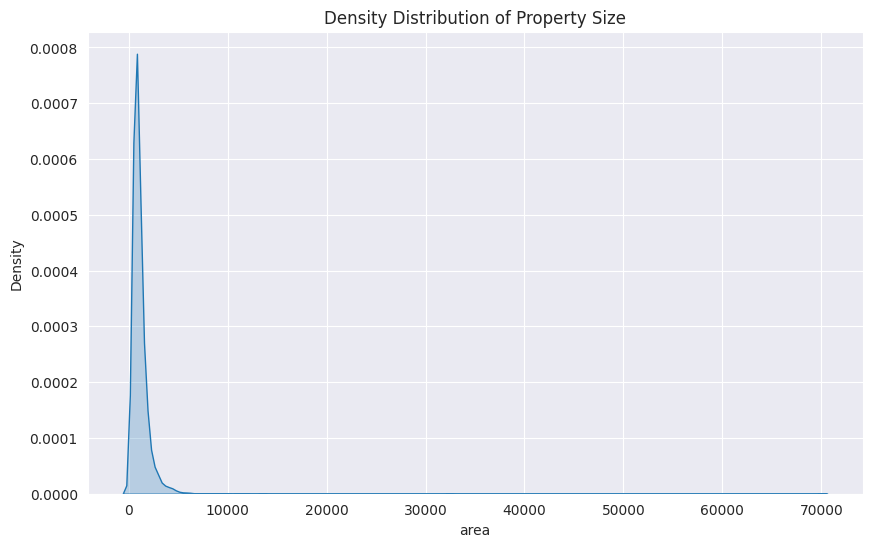

In [18]:
sns.kdeplot(df['area'], fill=True)
plt.title('Density Distribution of Property Size')
plt.show()

In [19]:
print("""
INSIGHT:
- Most properties fall in medium-size range
- Few extremely large properties exist
- Potential skewness in predictor variables
""")


INSIGHT:
- Most properties fall in medium-size range
- Few extremely large properties exist
- Potential skewness in predictor variables



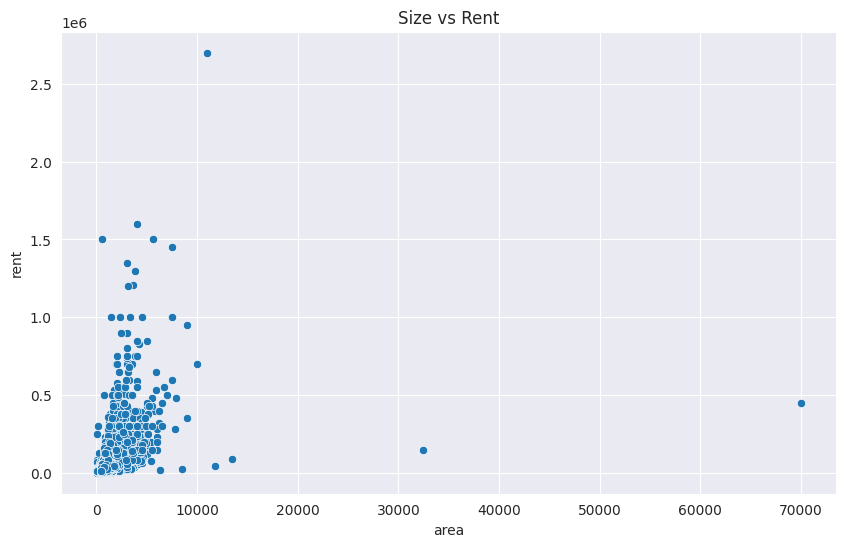

In [20]:
sns.scatterplot(data=df, x='area', y='rent')
plt.title('Size vs Rent')
plt.show()

In [21]:
print("""
INSIGHT:
- Positive linear relationship exists
- Larger houses generally have higher rents
- Good sign for Linear Regression suitability
""")


INSIGHT:
- Positive linear relationship exists
- Larger houses generally have higher rents
- Good sign for Linear Regression suitability



Text(0.5, 1.0, 'Regression Line: Size vs Rent')

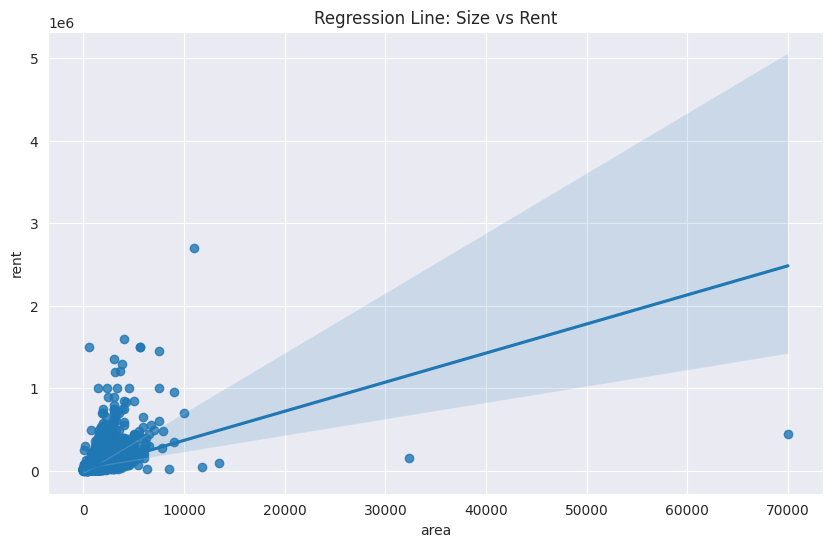

In [22]:
sns.regplot(data=df, x='area', y='rent')
plt.title("Regression Line: Size vs Rent")

In [23]:
print("""
INSIGHT:
- Regression line shows strong positive trend
- Some deviations indicate noise
- Size is one of the strongest predictors
""")


INSIGHT:
- Regression line shows strong positive trend
- Some deviations indicate noise
- Size is one of the strongest predictors



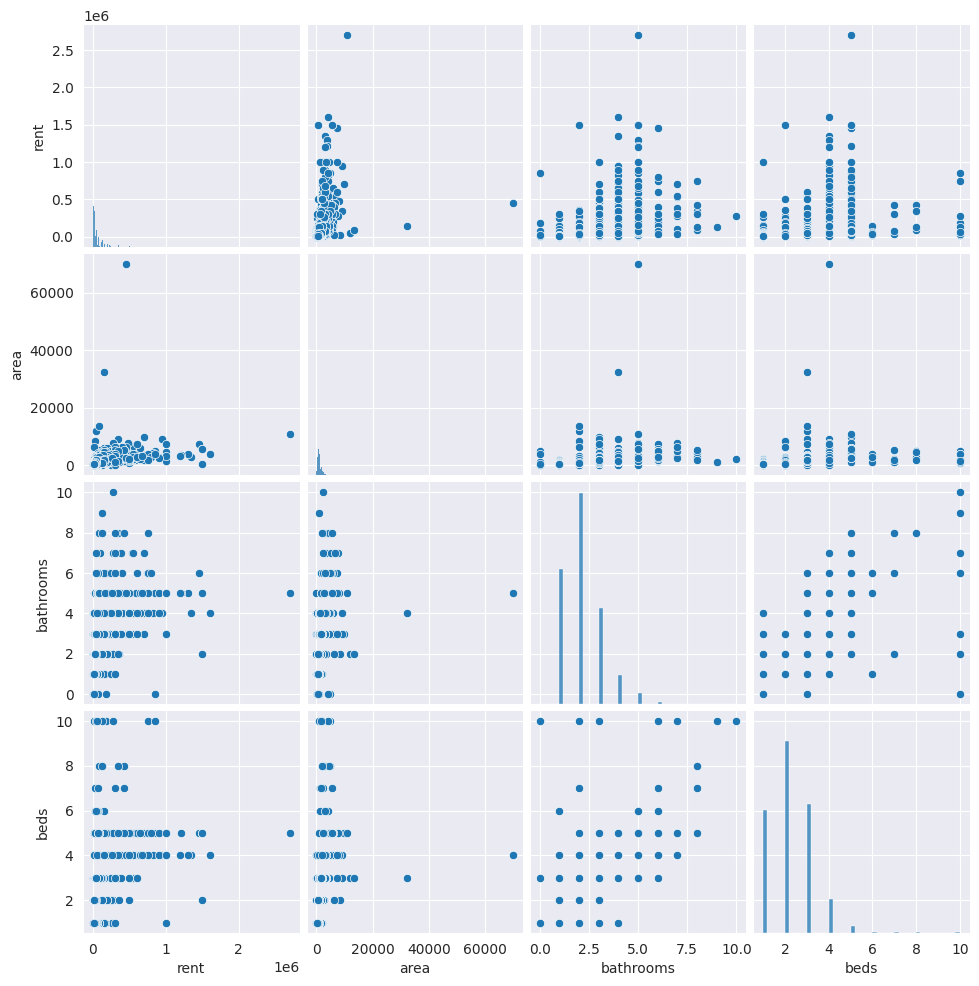

In [24]:
sns.pairplot(
    df[['rent','area','bathrooms','beds']]
)
plt.show()

In [25]:
print("""
INSIGHT:
- Size, beds, Bathroom positively correlate with Rent
- Helps identify multicollinearity
- Important before Linear Regression
""")


INSIGHT:
- Size, beds, Bathroom positively correlate with Rent
- Helps identify multicollinearity
- Important before Linear Regression



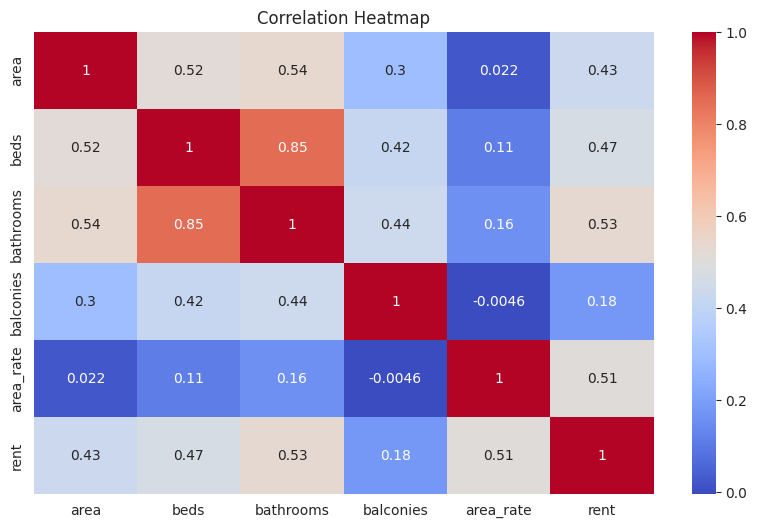

In [26]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [27]:
print("""
INSIGHT:
- Strong correlations among predictors
- High multicollinearity can destabilize coefficients
- Feature selection may be required
""")


INSIGHT:
- Strong correlations among predictors
- High multicollinearity can destabilize coefficients
- Feature selection may be required



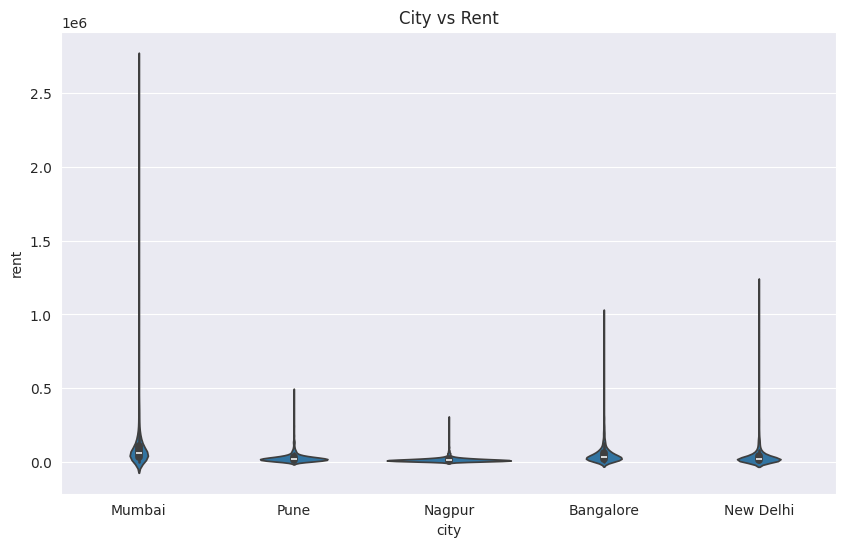

In [28]:
sns.violinplot(
    data=df,
    x='city',
    y='rent'
)
plt.title('City vs Rent')
plt.show()

In [29]:
print("""
INSIGHT:
- Furnished houses show higher rent distribution
- Distribution spread visible clearly
- Violin plot combines boxplot + KDE
""")


INSIGHT:
- Furnished houses show higher rent distribution
- Distribution spread visible clearly
- Violin plot combines boxplot + KDE



Text(0.5, 1.0, 'Area wise rant')

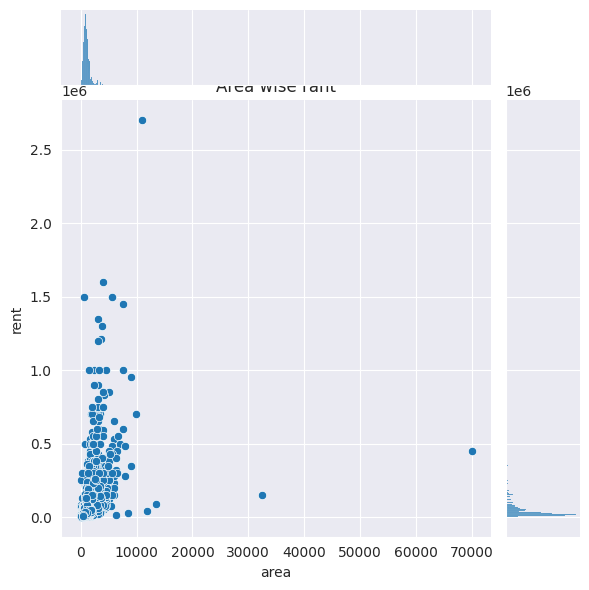

In [30]:
sns.jointplot(
    data=df,
    x='area',
    y='rent',
    kind='scatter'
)

plt.title("Area wise rant")

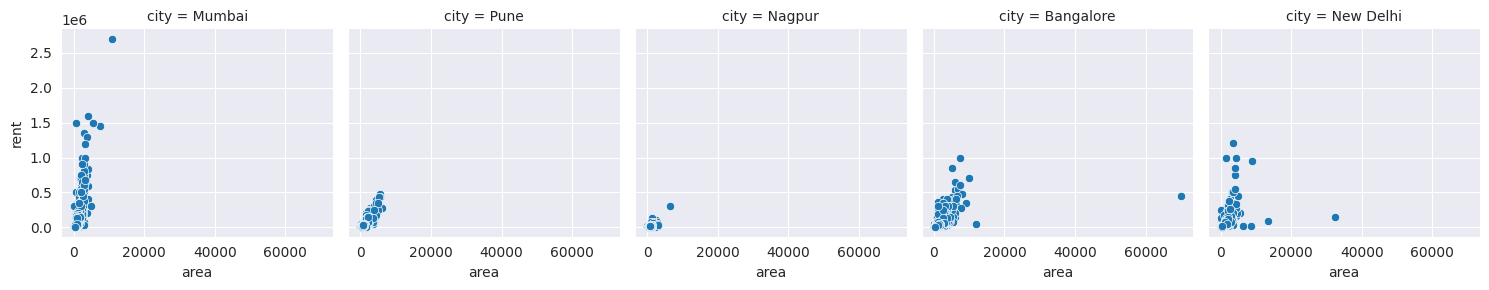

In [31]:
g = sns.FacetGrid(df, col='city')

g.map(sns.scatterplot, 'area', 'rent')

plt.show()

In [32]:
df

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0
...,...,...,...,...,...,...,...,...,...,...
7686,"3 BHK Flat for Rent in Saket, New Delhi",Saket,New Delhi,1750.0,3,3,0,Furnished,27.0,47000.0
7687,"2 BHK Flat for Rent in Phase 7 JP Nagar, Banga...",Phase 7 JP Nagar,Bangalore,1050.0,2,2,2,Semi-Furnished,27.0,28000.0
7688,"2 BHK Flat for Rent in Malpani Vivanta, Balewa...",Balewadi,Pune,734.0,2,2,2,Unfurnished,48.0,35000.0
7689,"1 BHK Flat for Rent in Shalimar bagh, New Delhi",Shalimar bagh,New Delhi,400.0,1,1,0,Semi-Furnished,38.0,15000.0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   int64  
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(4), object(3)
memory usage: 601.0+ KB


In [35]:
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,1,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,1,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,4,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,2,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,1,595.0,1,1,0,Unfurnished,25.0,15000.0


In [36]:
encoder = LabelEncoder()

cat_cols = [
    'city',
    'furnishing',
    'house_type'
]

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [38]:
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [39]:
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,2428,Goregaon East,1,897.0,2,2,0,1,134.0,120000.0
1,706,Powai,1,490.0,1,1,0,1,82.0,40000.0
2,1214,Mundhwa,4,550.0,1,1,0,2,22.0,12000.0
3,1944,Hingna,2,1000.0,2,2,0,2,8.0,8000.0
4,837,Mira Road,1,595.0,1,1,0,2,25.0,15000.0


In [44]:
X = df[['house_type','city','furnishing','area_rate','balconies','bathrooms']]
y = df['rent']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [47]:
predictions = model.predict(X_test)

In [48]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 28481.806399777222
RMSE: 64934.4317040134
R2 Score: 0.4373610817471766


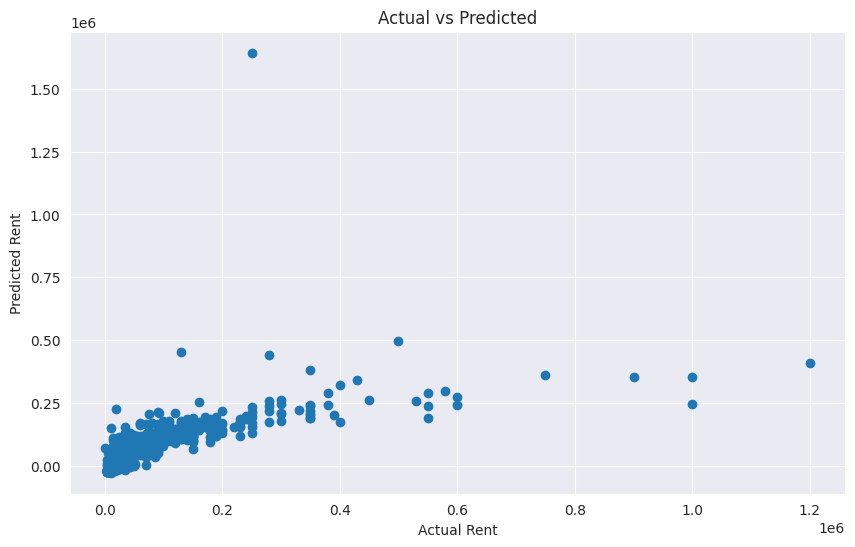

In [49]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")

plt.title("Actual vs Predicted")

plt.show()

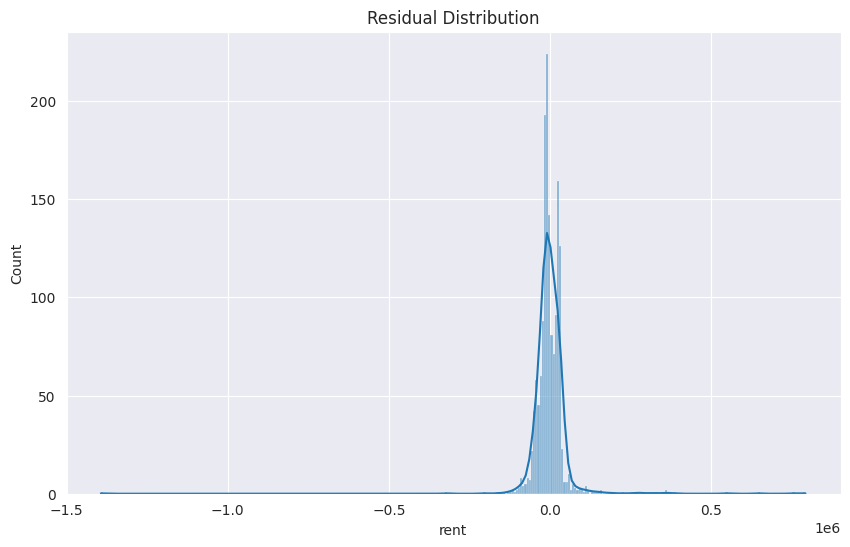

In [50]:
residuals = y_test - predictions

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

In [51]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df.sort_values(by='Coefficient',
                    ascending=False)

,Feature,Coefficient
5,bathrooms,43755.782885
3,area_rate,669.406683
0,house_type,0.257246
1,city,-1546.143273
4,balconies,-1785.691658
2,furnishing,-3267.077169
